In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy import array
from sklearn.decomposition import TruncatedSVD
from numpy import diag
from numpy import zeros
from scipy.linalg import svd

In [92]:
df = pd.DataFrame(np.array([[7, 6.5, 9.2, 8.6, 8], 
                           [7.5, 9.4, 7.3, 7, 7],
                           [7.6, 9.2, 8, 8, 7.5],
                           [5, 6.5, 6.5, 7, 9],
                           [6, 6, 7.8, 8.9, 7.3],
                           [7.8, 9.6, 7.7, 8, 6.5],
                           [6.3, 6.4, 8.2, 9, 7.2],
                           [7.9, 9.7, 7.5, 8, 6],
                           [6, 6, 6.5, 5.5, 8.7],
                           [6.8, 7.2, 8.7, 9, 7]]),
                 index = ['Lucia', 'Pedro', 'Ines', 'Luis', 'Andres', 'Ana', 'Carlos', 'Jose', 'Sonia', 'Maria'],
                 columns = ['Matematicas', 'Ciencias', 'Espanol', 'Historia', 'EdFisica'])
df

,Matematicas,Ciencias,Espanol,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.5
Carlos,6.3,6.4,8.2,9.0,7.2
Jose,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7
Maria,6.8,7.2,8.7,9.0,7.0


In [93]:
etiquetas = df.index
etiquetas

Index(['Lucia', 'Pedro', 'Ines', 'Luis', 'Andres', 'Ana', 'Carlos', 'Jose',
       'Sonia', 'Maria'],
      dtype='object')

In [94]:
A = df
U, s, VT = svd(A) # Obtencion de matrices cuyo producto arroja la matriz A
Sigma = zeros((A.shape[0], A.shape[1])) # creacion de matrices de ceros de la misma dimension que A
Sigma[:A.shape[1], :A.shape[1]] = diag(s)

In [95]:
# Para reconstruir la matri original
B = U.dot(Sigma.dot(VT))
print(B)

[[7.  6.5 9.2 8.6 8. ]
 [7.5 9.4 7.3 7.  7. ]
 [7.6 9.2 8.  8.  7.5]
 [5.  6.5 6.5 7.  9. ]
 [6.  6.  7.8 8.9 7.3]
 [7.8 9.6 7.7 8.  6.5]
 [6.3 6.4 8.2 9.  7.2]
 [7.9 9.7 7.5 8.  6. ]
 [6.  6.  6.5 5.5 8.7]
 [6.8 7.2 8.7 9.  7. ]]


In [96]:
# Reduccion a DOS Dimensiones
n_elements = 2

UReduced2 = U[:, :n_elements]

SigmaReduced2 = Sigma[:n_elements, :n_elements]

VTReduced2 = VT[:n_elements, :]

AReduced2 = UReduced2.dot(SigmaReduced2.dot(VTReduced2))
print('Matriz A transformada:')
print(AReduced2)

Matriz A transformada:
[[6.65563617 6.93068907 8.45496902 8.64041633 8.61053016]
 [7.50259774 9.15546106 7.47627701 7.62801112 6.39154032]
 [7.66288835 9.06253486 8.0774837  8.24477427 7.24032869]
 [5.61309793 5.65867129 7.41578628 7.58014066 7.72189396]
 [6.05941975 6.24591247 7.7953721  7.96693512 7.99698132]
 [7.83156613 9.60455223 7.73118336 7.88753689 6.55416982]
 [6.35785122 6.70021013 7.95486409 8.12861624 8.02875678]
 [7.86973795 9.80171752 7.53881312 7.68951159 6.21497236]
 [5.48053658 5.67061811 7.01789357 7.17215282 7.18015541]
 [6.86687283 7.53702066 8.13213661 8.30697925 7.93006916]]


In [97]:
T2 = UReduced2.dot(SigmaReduced2)

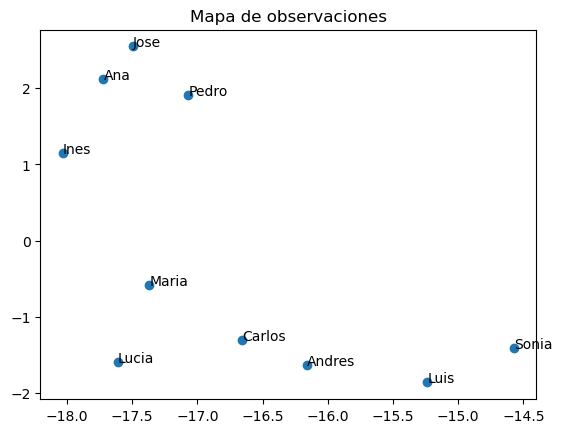

In [98]:
df2 = pd.DataFrame(T2, columns=['a', 'b'])
x = df2.iloc[:,0]
y = df2.iloc[:,1]
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title('Mapa de observaciones')
ax.scatter(x,y)

for i, txt in enumerate(etiquetas):
    ax.annotate(txt, (x[i], y[i]))
plt.show()

In [99]:
# Reduccion a 3 Dimensiones
n_elements = 3

UReduced3 = U[:, :n_elements]

SigmaReduced3 = Sigma[:n_elements, :n_elements]

VTReduced3 = VT[:n_elements, :]

AReduced3 = UReduced3.dot(SigmaReduced3.dot(VTReduced3))
print('Matriz A transformada:')
print(AReduced3)

Matriz A transformada:
[[6.65245886 6.72762726 8.69042319 9.08512051 8.09898421]
 [7.50649243 9.40437093 7.1876611  7.08289996 7.01858503]
 [7.66453175 9.1675645  7.95569976 8.01475998 7.50491554]
 [5.6205042  6.13200674 6.8669445  6.54353881 8.91430342]
 [6.05471948 5.94551744 8.14368606 8.62479847 7.24023707]
 [7.83115817 9.57847935 7.76141538 7.94463634 6.48848799]
 [6.35253602 6.36051578 8.34874639 8.87254488 7.17301112]
 [7.86825556 9.7069775  7.64866605 7.89699168 5.97630674]
 [5.49031524 6.29557293 6.29324613 5.80350542 8.75451889]
 [6.86123771 7.17687926 8.54972766 9.09568679 7.02281405]]


In [100]:
T3 = UReduced3.dot(SigmaReduced3)

In [101]:
from mpl_toolkits import mplot3d
%matplotlib inline

In [102]:
df3 = pd.DataFrame(T3, columns=['a', 'b', 'c'])
df3

,a,b,c
0,-17.608552,-1.598552,0.745737
1,-17.070743,1.906364,-0.914113
2,-18.032489,1.150281,-0.385718
3,-15.236045,-1.862909,-1.738307
4,-16.163433,-1.631878,1.103190
5,-17.720651,2.121542,0.095752
6,-16.655978,-1.307170,1.247515
7,-17.495911,2.547099,0.347929
8,-14.574976,-1.416864,-2.295124
9,-17.367933,-0.582289,1.322606


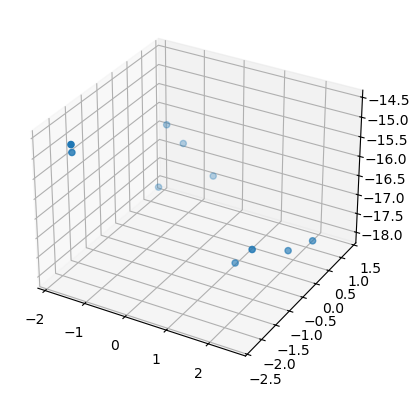

In [103]:
fig = plt.figure()
ax = plt.axes(projection='3d')
xline = df3['b']
yline = df3['c']
zline = df3['a']
ax.scatter3D(xline, yline, zline)
plt.show()

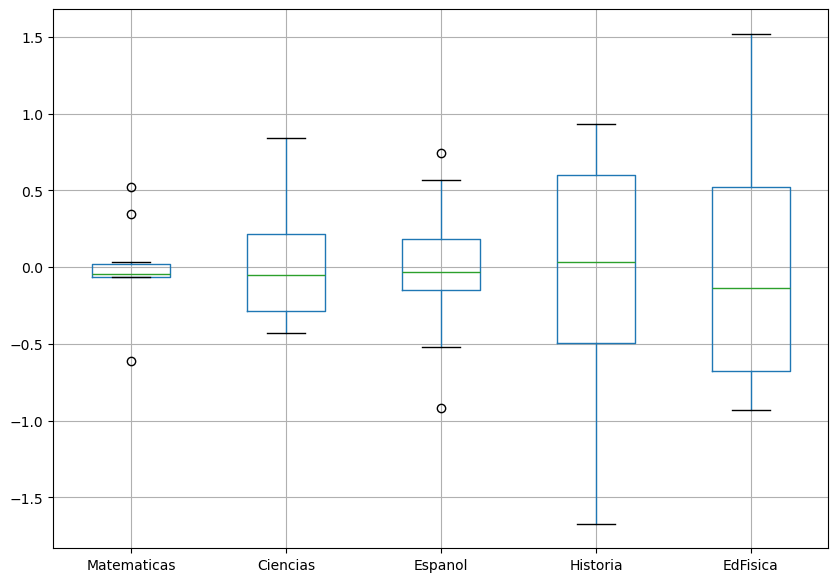

In [104]:
plt.figure(figsize = (10,7))
Error2 = B - AReduced2

dfError2 = pd.DataFrame(Error2, columns = df.columns)
dfError2.boxplot()
plt.show()

In [105]:
print('Errores promedio por columna')
Error2.mean(axis=0)

Errores promedio por columna


array([-2.04650684e-05,  1.32612606e-02, -1.94778869e-02, -2.45074289e-02,
        3.30602005e-02])

In [106]:
Error3 = B - AReduced3
print(Error3)

[[ 0.34754114 -0.22762726  0.50957681 -0.48512051 -0.09898421]
 [-0.00649243 -0.00437093  0.1123389  -0.08289996 -0.01858503]
 [-0.06453175  0.0324355   0.04430024 -0.01475998 -0.00491554]
 [-0.6205042   0.36799326 -0.3669445   0.45646119  0.08569658]
 [-0.05471948  0.05448256 -0.34368606  0.27520153  0.05976293]
 [-0.03115817  0.02152065 -0.06141538  0.05536366  0.01151201]
 [-0.05253602  0.03948422 -0.14874639  0.12745512  0.02698888]
 [ 0.03174444 -0.0069775  -0.14866605  0.10300832  0.02369326]
 [ 0.50968476 -0.29557293  0.20675387 -0.30350542 -0.05451889]
 [-0.06123771  0.02312074  0.15027234 -0.09568679 -0.02281405]]


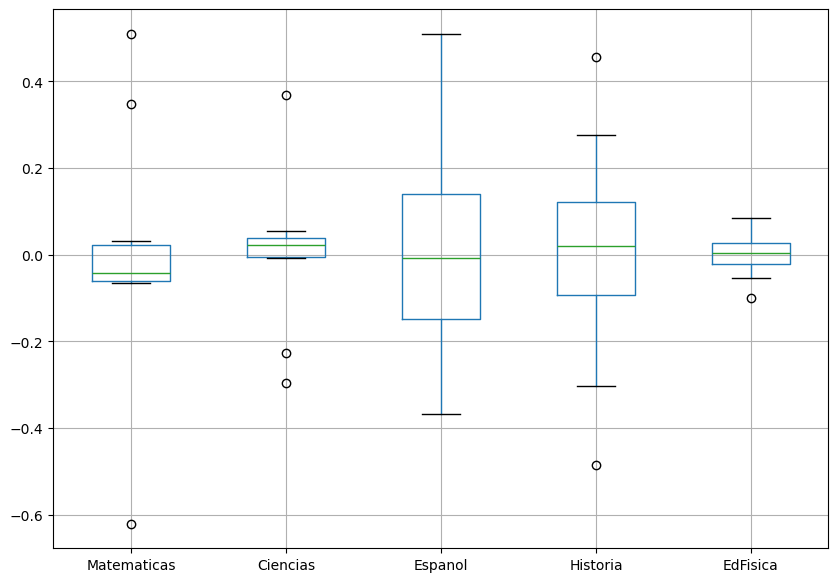

In [107]:
plt.figure(figsize = (10,7))

dfError3 = pd.DataFrame(Error3, columns = df.columns)
dfError3.boxplot()
plt.show()

In [108]:
print('Errores promedio por columna')
Error3.mean(axis=0)

Errores promedio por columna


array([-0.00022094,  0.00044883, -0.00462162,  0.00355172,  0.00078359])